# AT1 - Perceptron Manual

Aluno: Lucas do Nascimento Miura  
Disciplina: Aprendizado de Máquina
Professor: Ícaro Davies

## Introdução

O Perceptron é um algoritmo de classificação binária.

Neste trabalho, foi desenvolvido um modelo manual, sem uso de bibliotecas como numpy, com o objetivo de entender seu funcionamento.

O problema escolhido foi prever se uma pessoa irá comparecer a um evento.

In [17]:
# CARREGAR DADOS
import pandas as pd

df = pd.read_csv("../data/raw/eventos.csv")
df.head()



,interesse,distancia,preco,amigos,vai
0,9,2,30,1,1
1,8,3,40,1,1
2,7,5,50,1,1
3,6,7,60,0,0
4,5,10,70,0,0


In [18]:
# EXPLORAR DADOS
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   interesse  15 non-null     int64
 1   distancia  15 non-null     int64
 2   preco      15 non-null     int64
 3   amigos     15 non-null     int64
 4   vai        15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes


,interesse,distancia,preco,amigos,vai
count,15.000000,15.000000,15.00000,15.000000,15.000000
mean,6.200000,7.866667,58.00000,0.466667,0.466667
std,2.366432,5.152900,22.58318,0.516398,0.516398
min,2.000000,1.000000,20.00000,0.000000,0.000000
25%,4.500000,4.500000,42.50000,0.000000,0.000000
50%,6.000000,7.000000,60.00000,0.000000,0.000000
75%,8.000000,10.500000,72.50000,1.000000,1.000000
max,10.000000,20.000000,100.00000,1.000000,1.000000


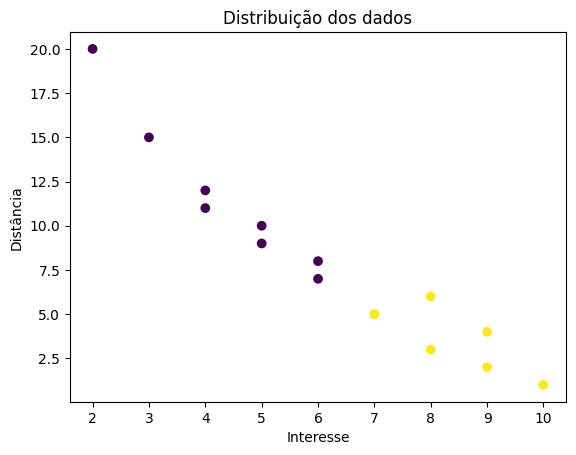

In [19]:
# GRÁFICO
import matplotlib.pyplot as plt

plt.scatter(df["interesse"], df["distancia"], c=df["vai"])
plt.xlabel("Interesse")
plt.ylabel("Distância")
plt.title("Distribuição dos dados")
plt.show()

In [20]:
# PREPARAR DADOS
x1 = list(df["interesse"])
x2 = list(df["distancia"])
y = list(df["vai"])

In [21]:
# IMPLEMENTAR O PERCEPTRON
class Perceptron:
    def __init__(self, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.w1 = 0
        self.w2 = 0
        self.bias = 0

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x1, x2):
        soma = (x1 * self.w1) + (x2 * self.w2) + self.bias
        return self.activation(soma)

    def train(self, X1, X2, Y):
        for _ in range(self.epochs):
            for i in range(len(Y)):
                y_pred = self.predict(X1[i], X2[i])
                erro = Y[i] - y_pred

                self.w1 += self.lr * erro * X1[i]
                self.w2 += self.lr * erro * X2[i]
                self.bias += self.lr * erro

In [22]:
# TREINAR
p = Perceptron()
p.train(x1, x2, y)

In [23]:
# TESTAR
for i in range(len(y)):
    print(f"Real: {y[i]} | Previsto: {p.predict(x1[i], x2[i])}")

Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0
Real: 1 | Previsto: 1
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 1 | Previsto: 1
Real: 0 | Previsto: 0
Real: 0 | Previsto: 0


In [24]:
print(p.predict(9, 2))
print(p.predict(2, 20))

1
0


## Conclusão

O modelo conseguiu aprender padrões simples de decisão.

Mesmo sendo um modelo básico, ele demonstra como algoritmos de aprendizado funcionam internamente.